# Module 1.1 — Probability Theory & Statistics  
## The Mathematical Language of Uncertainty

---

### The Paradigm Shift: From Prediction to Probabilistic Reasoning

Markets are not puzzles to be solved. They are **uncertain systems** to be navigated with rigor and humility. Markets do not reward raw intelligence—they reward **disciplined thinking under uncertainty**.

Quantitative finance does not begin with prediction. It begins with **honest acknowledgment of ignorance**, structured through mathematics.

#### The Amateur vs. Professional Mindset

Most beginners approach trading as a prediction problem:

**Beginners ask:**
- Where will price go?
- Is this signal real?
- Is this pattern bullish?


Professionals approach it differently:

**Professionals ask:**
- What is the **distribution** of outcomes?
- What is the **expected value** and is it positive after costs?
- What is the **variance** and can I survive it?
- What are the **tail risks** that could destroy my capital?
- What is the **sample size** required to distinguish signal from noise?

---

### Core Philosophy

> *"A probability model is not a claim about truth. It is a structured admission of ignorance."*

- **Probability theory** is the grammar of uncertainty
- **Statistics** is the method of learning from data
- **Quantitative finance** is the art of making decisions under uncertainty using statistics and probability theory.

This notebook builds the probabilistic foundation that every robust trader, quant researcher, and risk manager must internalize.

---

### Learning Objectives

By the end of this module, you will:

1. **Master probability spaces** $(\Omega, \mathcal{F}, \mathbb{P})$ and their role in modeling market uncertainty
2. **Understand random variables** as measurable functions mapping outcomes to numbers
3. **Compute and interpret** expected value, variance, skewness, kurtosis, and cumulants
4. **Analyze joint distributions** through covariance, correlation, and copulas
5. **Apply the Law of Large Numbers** to understand edge realization
6. **Leverage the Central Limit Theorem** for statistical inference
7. **Conduct rigorous hypothesis testing** while avoiding common pitfalls
8. **Simulate everything** to build intuition and validate theory

---

### Module Contents

1. **Probability Spaces & Random Variables** — The axiomatic foundation
2. **Expected Value, Variance & Moments** — Characterizing distributions
3. **Joint Distributions & Dependence** — Portfolio theory foundations
4. **Limit Theorems (LLN & CLT)** — Why statistical inference works
5. **Hypothesis Testing in Trading** — Distinguishing signal from noise
6. **Advanced Topics** — Bootstrap methods, multiple testing, practical applications

---

*"Before you optimize portfolios or backtest strategies, you must understand the probabilistic substrate upon which all quantitative finance rests."*



In [3]:
# ========================================
# Initial Setup and Configuration
# ========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm, t, chi2, skew, kurtosis
from typing import Tuple, List, Optional, Dict, Any
import warnings
from datetime import datetime

warnings.filterwarnings('ignore')

# Set random seed for reproducibility
RANDOM_SEED = 60
np.random.seed(RANDOM_SEED)

# Configure plotting aesthetics
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Global plot configuration
PLOT_CONFIG = {
    'figure.figsize': (12, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 100
}
plt.rcParams.update(PLOT_CONFIG)

print("="*70)
print("MODULE 1.1: PROBABILITY THEORY & STATISTICS")
print("="*70)
print(f"✓ Environment configured successfully")
print(f"✓ Random seed: {RANDOM_SEED}")
print(f"✓ NumPy version: {np.__version__}")
print(f"✓ Pandas version: {pd.__version__}")
print(f"✓ Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*70)

MODULE 1.1: PROBABILITY THEORY & STATISTICS
✓ Environment configured successfully
✓ Random seed: 60
✓ NumPy version: 2.4.3
✓ Pandas version: 3.0.1
✓ Timestamp: 2026-04-16 20:47:17


---

## 1. Probability Spaces, Random Variables, and Distributions

### 1.1 The Axiomatic Foundation: Kolmogorov's Probability Space

Every probability model in finance rests on the **probability triple**:

$$
(\Omega, \mathcal{F}, \mathbb{P})
$$

This compact notation is one of the most powerful conceptual tools in finance that encodes profound structure:

#### Components Explained

1. **$\Omega$ — Sample Space (The Universe of Possibilities)**
   - The set of **all possible outcomes**
   - In finance: all possible future price paths, return sequences, market states
   - Example: $\Omega = \{\text{all possible daily returns over next year}\}$
   - **Key insight**: $\Omega$ is typically infinite and unobservable directly

2. **$\mathcal{F}$ — Sigma-Algebra (Measurable Events)**
   - A collection of **measurable subsets** of $\Omega$
   - Events we can assign probabilities to
   - Must satisfy:
     - $\Omega \in \mathcal{F}$ (certainty is measurable)
     - If $A \in \mathcal{F}$, then $A^c \in \mathcal{F}$ (closed under complements)
     - If $A_1, A_2, \ldots \in \mathcal{F}$, then $\bigcup_{i=1}^{\infty} A_i \in \mathcal{F}$ (closed under countable unions)

3. **$\mathbb{P}$ — Probability Measure (Belief Assignment)**
   - A function $\mathbb{P}: \mathcal{F} \rightarrow [0,1]$ satisfying Kolmogorov's axioms:
     - **Axiom 1**: $\mathbb{P}(A) \geq 0$ for all $A \in \mathcal{F}$
     - **Axiom 2**: $\mathbb{P}(\Omega) = 1$
     - **Axiom 3**: For disjoint $A_i$, $\mathbb{P}(\bigcup A_i) = \sum \mathbb{P}(A_i)$


In markets, $\Omega$ is not dice outcomes. It is the set of all possible future return paths. In other words, In finance, 
$\Omega$ is enormous. It contains every possible configuration of future price movements. We do not observe 
$\Omega$. We infer it. 

Every quantitative model — from Black–Scholes to GARCH to reinforcement learning — implicitly assumes a probability space.

The difference between amateurs and professionals is not access to information. It is awareness of the underlying probabilistic structure.

---

### 1.2 Random Variables

A **random variable** is a measurable function:

$$X : \Omega \rightarrow \mathbb{R}$$

It translates uncertainty into computation.

In finance, examples include:

- Daily return of an asset
- Portfolio PnL (Profit and Loss)
- Drawdowns
- Volatility
- Time to recovery

Once uncertainty becomes numeric, it becomes analyzable. Expected value, variance, correlation, tail probabilities — these are not abstract objects. They are decision-making tools.

A trader who thinks in single outcomes asks:
> "Will this trade work?"

A trader who thinks in random variables asks:

> "What is the distribution of outcomes?"

That shift changes everything.

### Philosophical Insight

A probability model is not truth. It is a disciplined structure imposed on uncertainty.

Professional traders differ from amateurs in one crucial way: They reason in distributions — not outcomes.

---

### 1.3 Key Distributions in Finance

Each distribution makes a specific assumption about the shape of uncertainty. Choosing the wrong distribution is not a technicality — it determines whether your model survives contact with reality.

---

#### Normal Distribution

$$X \sim \mathcal{N}(\mu, \sigma^2), \qquad f(x) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\!\left(-\frac{(x-\mu)^2}{2\sigma^2}\right), \quad x \in (-\infty, \infty)$$

| Parameter | Symbol | Range | Role |
|-----------|--------|-------|------|
| Location (mean) | $\mu$ | $\mu \in \mathbb{R}$ | Shifts the center of the distribution; equals $\mathbb{E}[X]$ |
| Scale (std dev) | $\sigma$ | $\sigma > 0$ | Controls spread; $\sigma^2 = \text{Var}(X)$ |

**Key properties:**

- **Moments**: $\mathbb{E}[X]=\mu$, $\text{Var}(X)=\sigma^2$, $\text{Skew}=0$, $\text{Kurt}=3$ (excess kurtosis = 0)
- **Symmetry**: perfectly symmetric around $\mu$; no tail asymmetry
- **68–95–99.7 rule**: $\approx 68\%$ of mass within $\pm\sigma$, $95\%$ within $\pm 2\sigma$, $99.7\%$ within $\pm 3\sigma$
- **Closure under addition**: sum of independent normals is normal — the foundation of portfolio theory

**Finance use:** Benchmark model for daily returns in Black–Scholes and Markowitz frameworks. Fast and analytically tractable, but systematically underestimates tail events.

**Finance warning:** Real returns have excess kurtosis $\approx 4$–$8$. A 5-sigma move that should occur once in 3.5 million days under normality is observed multiple times per decade.

---

#### Student-t Distribution

$$X \sim t_\nu(\mu, \sigma^2), \qquad f(x) = \frac{\Gamma\!\left(\tfrac{\nu+1}{2}\right)}{\sqrt{\nu\pi}\,\sigma\,\Gamma\!\left(\tfrac{\nu}{2}\right)} \left(1 + \frac{(x-\mu)^2}{\nu\sigma^2}\right)^{-\frac{\nu+1}{2}}, \quad x \in (-\infty,\infty)$$

| Parameter | Symbol | Range | Role |
|-----------|--------|-------|------|
| Degrees of freedom | $\nu$ | $\nu > 0$ | Tail heaviness; lower $\nu$ → fatter tails |
| Location | $\mu$ | $\mu \in \mathbb{R}$ | Center of distribution; equals $\mathbb{E}[X]$ when $\nu > 1$ |
| Scale | $\sigma$ | $\sigma > 0$ | Spread; note $\text{Var}(X) = \sigma^2 \tfrac{\nu}{\nu-2}$ for $\nu > 2$ |

**Key properties:**

- **Moments exist conditionally**: $\mathbb{E}[X]$ exists only if $\nu > 1$; $\text{Var}(X)$ only if $\nu > 2$; kurtosis only if $\nu > 4$
- **Excess kurtosis**: $\tfrac{6}{\nu - 4}$ for $\nu > 4$ — decreases toward 0 as $\nu \to \infty$
- **Convergence to Normal**: as $\nu \to \infty$, $t_\nu \to \mathcal{N}(\mu, \sigma^2)$; in practice $\nu \geq 30$ is near-normal
- **Symmetry**: symmetric around $\mu$ for all $\nu$; zero skewness

**Practical $\nu$ guide for daily returns:**

| $\nu$ | Tail behavior | Finance context |
|-------|--------------|-----------------|
| 3–4 | Very fat tails | Emerging markets, crypto, stressed periods |
| 5–6 | Fat tails | Equities (common empirical fit) |
| 10–15 | Moderate tails | FX, investment-grade credit |
| $\geq 30$ | Near-Gaussian | Highly liquid large-caps, short windows |

**Finance use:** Preferred over Normal for return modeling, VaR, and option pricing when tail risk matters. A Student-t with $\nu = 5$ is a common empirical fit for equity daily returns.

---

#### Log-Normal Distribution

$$\ln X \sim \mathcal{N}(\mu, \sigma^2), \qquad f(x) = \frac{1}{x\,\sigma\sqrt{2\pi}} \exp\!\left(-\frac{(\ln x - \mu)^2}{2\sigma^2}\right), \quad x > 0$$

| Parameter | Symbol | Range | Role |
|-----------|--------|-------|------|
| Log-mean | $\mu$ | $\mu \in \mathbb{R}$ | Mean of $\ln X$; controls the scale of $X$ |
| Log-std | $\sigma$ | $\sigma > 0$ | Std dev of $\ln X$; controls spread and right-skew |

**Key properties:**

- **Support**: $x > 0$ — prices can never go negative (unlike Normal)
- **Moments of $X$**: $\mathbb{E}[X] = e^{\mu + \sigma^2/2}$, $\text{Var}(X) = (e^{\sigma^2}-1)e^{2\mu+\sigma^2}$
- **Right-skewed**: heavier right tail than left; skewness $= (e^{\sigma^2}+2)\sqrt{e^{\sigma^2}-1} > 0$
- **Multiplicative returns**: if $X_t = X_0 e^{R_t}$ and $R_t \sim \mathcal{N}(\mu, \sigma^2)$, then $X_t$ is log-normal

**Finance use:** The natural model for **asset prices** (not returns). Black–Scholes assumes log-normal prices. Also used for volatility modeling and option payoff distributions.

**Finance warning:** Log-normality still underestimates crash risk. Real prices have fatter left tails than log-normal implies.

---

#### Laplace (Double-Exponential) Distribution

$$X \sim \text{Laplace}(\mu, b), \qquad f(x) = \frac{1}{2b} \exp\!\left(-\frac{|x - \mu|}{b}\right), \quad x \in (-\infty, \infty)$$

| Parameter | Symbol | Range | Role |
|-----------|--------|-------|------|
| Location | $\mu$ | $\mu \in \mathbb{R}$ | Median and mode; equals $\mathbb{E}[X]$ |
| Scale | $b$ | $b > 0$ | Controls spread; $\text{Var}(X) = 2b^2$ |

**Key properties:**

- **Moments**: $\mathbb{E}[X]=\mu$, $\text{Var}(X)=2b^2$, $\text{Skew}=0$, excess kurtosis $= 3$
- **Sharper peak and heavier tails** than Normal — the probability mass "moved" from the shoulders to both the center and the tails
- **Exponential tails**: tail probability decays as $e^{-|x|/b}$, slower than Gaussian $e^{-x^2}$ but faster than power-law

**Finance use:** Simple, symmetric fat-tail alternative to Normal. Appears in certain high-frequency return models and as a regularization prior (LASSO) in portfolio optimization. Less common than Student-t, but analytically convenient.

---

#### Chi-Squared Distribution

$$X \sim \chi^2_k, \qquad f(x) = \frac{x^{k/2-1} e^{-x/2}}{2^{k/2}\,\Gamma(k/2)}, \quad x > 0$$

| Parameter | Symbol | Range | Role |
|-----------|--------|-------|------|
| Degrees of freedom | $k$ | $k \in \mathbb{Z}^+$ | Shape; $k$ independent standard normals squared sum to $\chi^2_k$ |

**Key properties:**

- **Moments**: $\mathbb{E}[X]=k$, $\text{Var}(X)=2k$
- **Special case**: $\chi^2_1 = Z^2$ where $Z \sim \mathcal{N}(0,1)$
- **Asymmetric and non-negative**: right-skewed for small $k$, approaches Normal as $k \to \infty$
- **Additive**: sum of independent $\chi^2_{k_i}$ is $\chi^2_{\sum k_i}$

**Finance use:** Foundation of statistical tests — **Jarque–Bera** normality test, **Ljung–Box** autocorrelation test, and **likelihood ratio tests** all use $\chi^2$ critical values. Also appears in covariance matrix estimation (Wishart distribution).


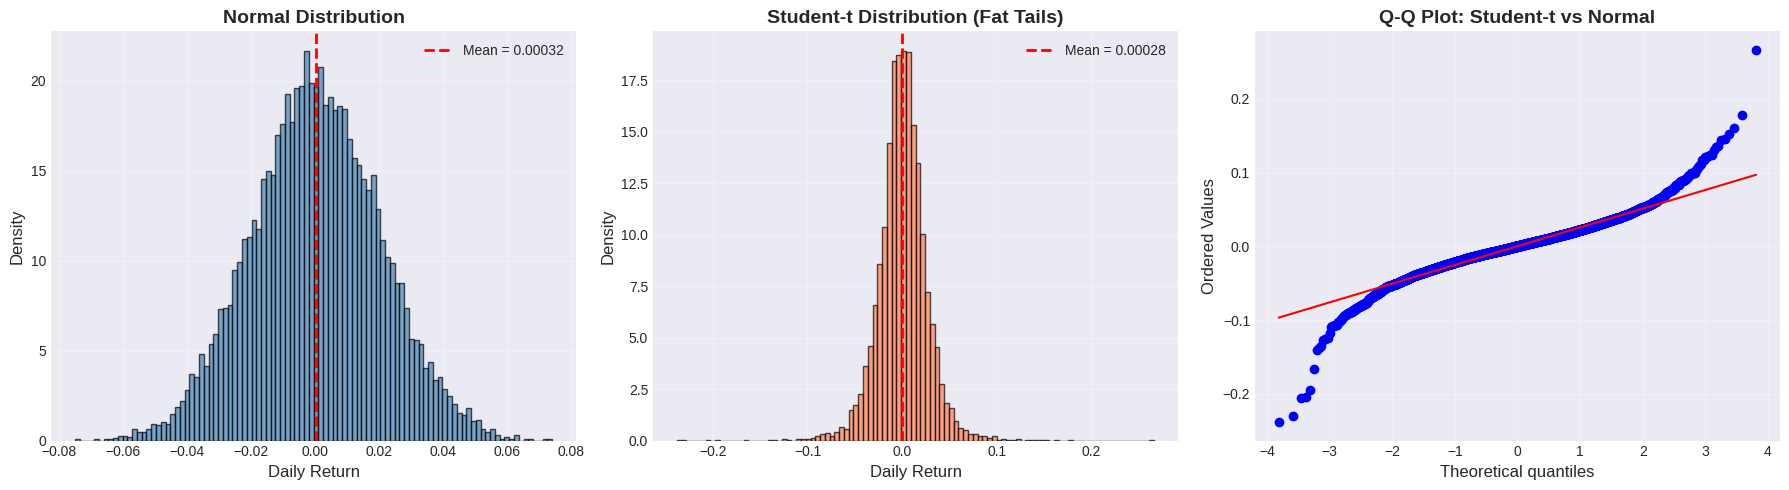


DISTRIBUTION COMPARISON
Normal: Mean = 0.000321, Std = 0.020066
Student-t: Mean = 0.000278, Std = 0.026002


In [4]:
# ========================================
# Simulating Return Distributions
# ========================================

def simulate_returns(
    mu: float = 0.0005,
    sigma: float = 0.02,
    n: int = 10000,
    distribution: str = 'normal'
) -> np.ndarray:
    """
    Simulate daily returns from various distributions.
    
    Parameters:
    -----------
    mu : float
        Expected daily return
    sigma : float
        Daily volatility
    n : int
        Number of samples
    distribution : str
        'normal', 't', or 'lognormal'
    
    Returns:
    --------
    returns : np.ndarray
        Simulated returns
    """
    if distribution == 'normal':
        returns = np.random.normal(mu, sigma, n)
    elif distribution == 't':
        returns = stats.t.rvs(df=5, loc=mu, scale=sigma, size=n)
    elif distribution == 'lognormal':
        returns = np.random.lognormal(mu, sigma, n) - 1
    else:
        raise ValueError(f"Unknown distribution: {distribution}")
    
    return returns

# Simulate returns
n_samples = 10000
mu_daily = 0.0005  # ~13% annualized
sigma_daily = 0.02  # ~32% annualized volatility

returns_normal = simulate_returns(mu_daily, sigma_daily, n_samples, 'normal')
returns_t = simulate_returns(mu_daily, sigma_daily, n_samples, 't')

# Visualize distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(returns_normal, bins=100, alpha=0.7, density=True, color='steelblue', edgecolor='black')
axes[0].axvline(returns_normal.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean = {returns_normal.mean():.5f}')
axes[0].set_title('Normal Distribution', fontweight='bold')
axes[0].set_xlabel('Daily Return')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(returns_t, bins=100, alpha=0.7, density=True, color='coral', edgecolor='black')
axes[1].axvline(returns_t.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean = {returns_t.mean():.5f}')
axes[1].set_title('Student-t Distribution (Fat Tails)', fontweight='bold')
axes[1].set_xlabel('Daily Return')
axes[1].set_ylabel('Density')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

stats.probplot(returns_t, dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot: Student-t vs Normal', fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("DISTRIBUTION COMPARISON")
print("="*60)
print(f"Normal: Mean = {returns_normal.mean():.6f}, Std = {returns_normal.std():.6f}")
print(f"Student-t: Mean = {returns_t.mean():.6f}, Std = {returns_t.std():.6f}")

---

## 2. Expected Value, Variance, and Higher Moments

### 2.1 Expected Value (First Moment)

$$\mathbb{E}[X] = \int_{-\infty}^{\infty} x \, f_X(x) \, dx = \mu$$

Expected value represents the long-run average outcome.

In trading:
- It represents your statistical edge, but the expected value alone is dangerous. 
- But it says nothing about path or survival.

A strategy with positive expected return can still go bankrupt if variance is too large.


**Trading Interpretation**: Your statistical edge

### 2.2 Variance (Second Central Moment)

$$\text{Var}(X) = \mathbb{E}[(X - \mu)^2] = \mathbb{E}[X^2] - (\mathbb{E}[X])^2 = \sigma^2$$

Variance measures dispersion, or let's say an instability around the mean.
In finance, variance is volatility — the cost of uncertainty.

Volatility is not just noise. It determines survival.

Two strategies may have identical expected returns.
The one with lower variance compounds more reliably and survives deeper drawdowns.

Expected value defines opportunity. Variance defines fragility.

**Volatility Drag Formula**:
$$\text{Geometric Mean} \approx \text{Arithmetic Mean} - \frac{\sigma^2}{2}$$

### 2.3 Higher Moments: The Shape of Risk
Markets are not Gaussian. Empirical returns frequently exhibit
- Negative skewness (large downside moves),
- Excess kurtosis (fat tails).


#### 2.3.1 Skewness (Third Standardized Moment)
Skewness measures asymmetry.
- Skewness → asymmetry

$$\text{Skew}(X) = \mathbb{E}\left[\left(\frac{X - \mu}{\sigma}\right)^3\right] = \frac{\mathbb{E}[(X-\mu)^3]}{\sigma^3}$$

**Empirical fact**: S&P 500 daily returns have **negative skewness** ≈ -0.3 to -0.5

#### 2.3.2 Kurtosis (Fourth Standardized Moment)
Kurtosis measures tail heaviness:
- Kurtosis → fat tails

$$\text{Kurt}(X) = \mathbb{E}\left[\left(\frac{X - \mu}{\sigma}\right)^4\right] = \frac{\mathbb{E}[(X-\mu)^4]}{\sigma^4}$$

**Excess kurtosis**: Kurt(X) - 3

**Historical Examples:**
- **1987 Black Monday**: -22% move (should be 1 in $10^{50}$ years under normality)
- **2008 Financial Crisis**: Multiple 10-sigma events
- **LTCM Collapse**: Ignored fat tails


Markets often exhibit:
- Negative skew
- Excess kurtosis

These are not academic details. They are why strategies blow up.
Many financial crises are kurtosis events. Strategies that appear stable under Gaussian assumptions collapse under fat-tailed reality. Ignoring higher moments  is not simplification, it is negligence. 

In [5]:
# ========================================
# Computing and Visualizing Moments
# ========================================

def compute_moments(returns: np.ndarray, name: str = "Returns") -> pd.Series:
    """Compute comprehensive moment statistics."""
    moments = pd.Series({
        'Mean': np.mean(returns),
        'Std Dev': np.std(returns, ddof=1),
        'Variance': np.var(returns, ddof=1),
        'Skewness': stats.skew(returns),
        'Kurtosis': stats.kurtosis(returns, fisher=True),
        'Min': np.min(returns),
        'Max': np.max(returns),
        '5th Percentile': np.percentile(returns, 5),
        '95th Percentile': np.percentile(returns, 95),
    }, name=name)
    return moments

moments_normal = compute_moments(returns_normal, "Normal")
moments_t = compute_moments(returns_t, "Student-t")

moments_comparison = pd.DataFrame([moments_normal, moments_t]).T

print("\n" + "="*70)
print("MOMENT COMPARISON: NORMAL vs STUDENT-T")
print("="*70)
print(moments_comparison.to_string())
print("\n💡 Student-t has fat tails → More extreme events than normal!")


MOMENT COMPARISON: NORMAL vs STUDENT-T
                   Normal  Student-t
Mean             0.000321   0.000278
Std Dev          0.020067   0.026003
Variance         0.000403   0.000676
Skewness         0.016658  -0.116129
Kurtosis        -0.052581   6.052943
Min             -0.074957  -0.237983
Max              0.074130   0.266242
5th Percentile  -0.032609  -0.039420
95th Percentile  0.033575   0.039577

💡 Student-t has fat tails → More extreme events than normal!


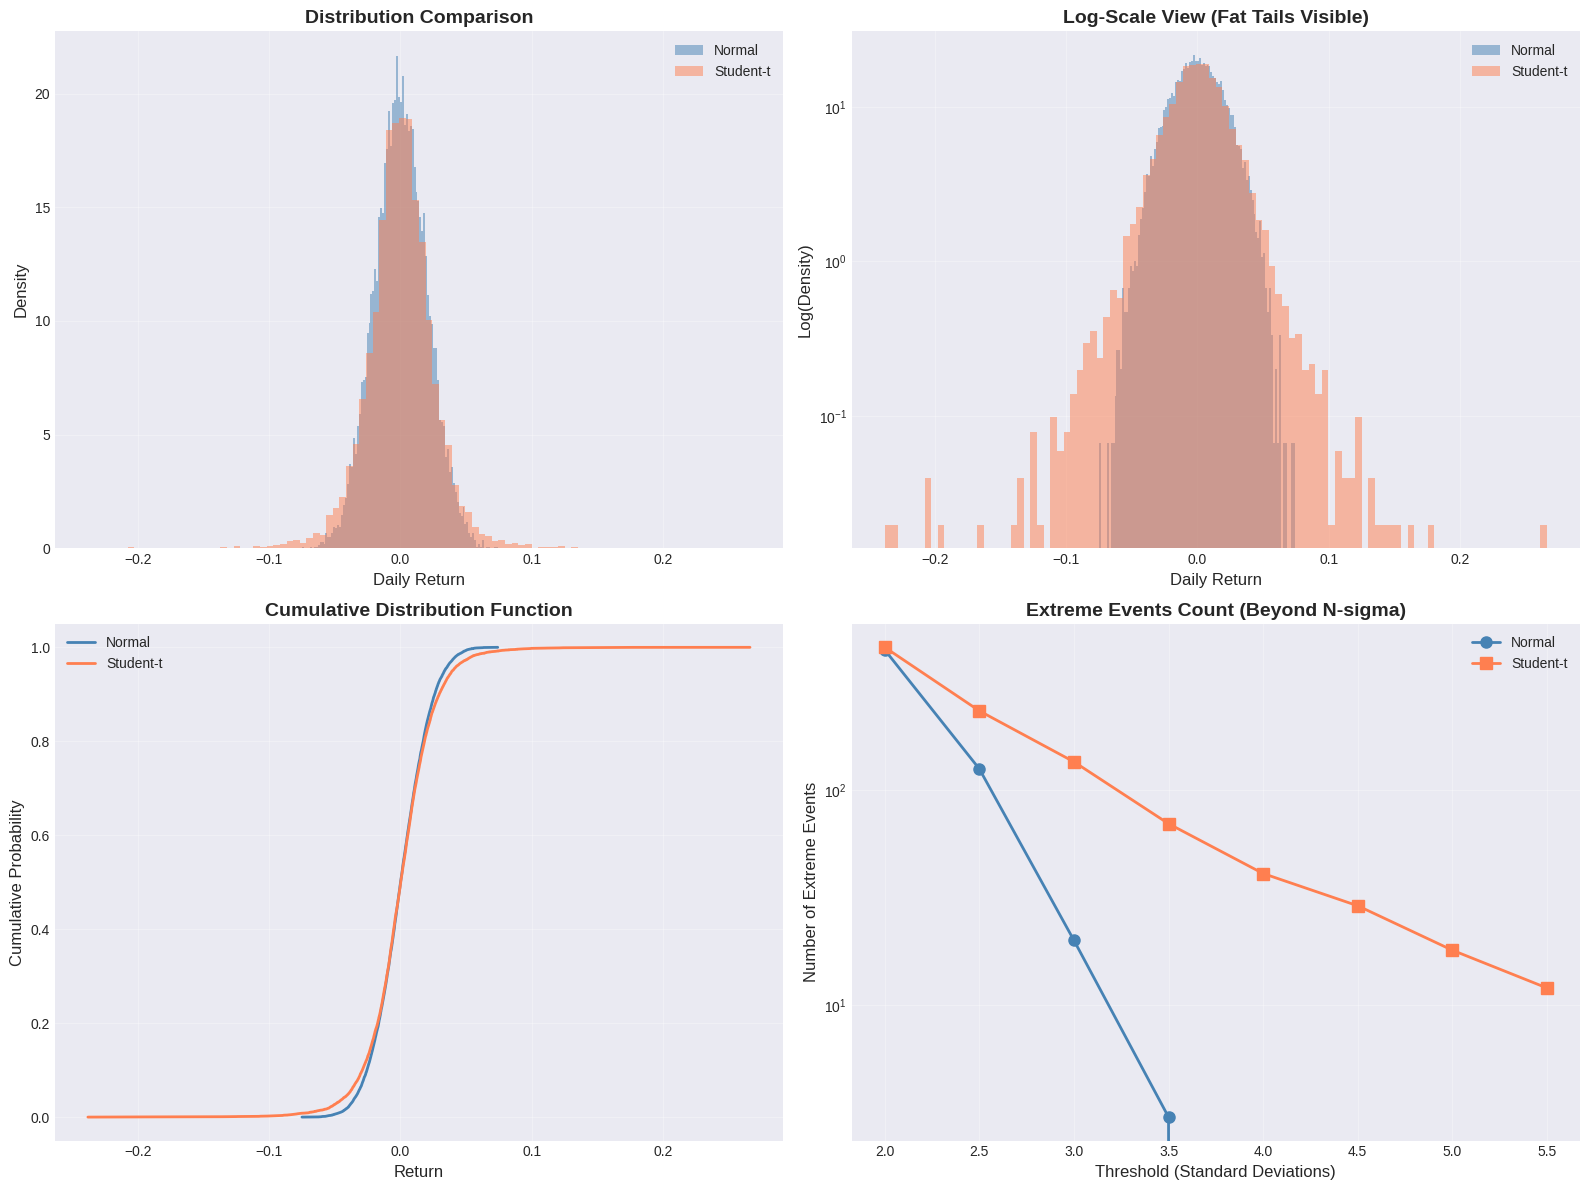

In [6]:
# ========================================
# Visualizing Fat Tails
# ========================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Histogram overlay
axes[0, 0].hist(returns_normal, bins=100, alpha=0.5, density=True, label='Normal', color='steelblue')
axes[0, 0].hist(returns_t, bins=100, alpha=0.5, density=True, label='Student-t', color='coral')
axes[0, 0].set_title('Distribution Comparison', fontweight='bold')
axes[0, 0].set_xlabel('Daily Return')
axes[0, 0].set_ylabel('Density')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Log-scale
axes[0, 1].hist(returns_normal, bins=100, alpha=0.5, density=True, label='Normal', color='steelblue')
axes[0, 1].hist(returns_t, bins=100, alpha=0.5, density=True, label='Student-t', color='coral')
axes[0, 1].set_yscale('log')
axes[0, 1].set_title('Log-Scale View (Fat Tails Visible)', fontweight='bold')
axes[0, 1].set_xlabel('Daily Return')
axes[0, 1].set_ylabel('Log(Density)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Empirical CDF
sorted_normal = np.sort(returns_normal)
sorted_t = np.sort(returns_t)
cdf_normal = np.arange(1, len(sorted_normal) + 1) / len(sorted_normal)
cdf_t = np.arange(1, len(sorted_t) + 1) / len(sorted_t)

axes[1, 0].plot(sorted_normal, cdf_normal, label='Normal', linewidth=2, color='steelblue')
axes[1, 0].plot(sorted_t, cdf_t, label='Student-t', linewidth=2, color='coral')
axes[1, 0].set_title('Cumulative Distribution Function', fontweight='bold')
axes[1, 0].set_xlabel('Return')
axes[1, 0].set_ylabel('Cumulative Probability')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Extreme events count
thresholds = np.arange(2, 6, 0.5)
sigma_normal = returns_normal.std()
sigma_t = returns_t.std()

extreme_normal = [np.sum(np.abs(returns_normal) > t * sigma_normal) for t in thresholds]
extreme_t = [np.sum(np.abs(returns_t) > t * sigma_t) for t in thresholds]

axes[1, 1].plot(thresholds, extreme_normal, marker='o', label='Normal', linewidth=2, markersize=8, color='steelblue')
axes[1, 1].plot(thresholds, extreme_t, marker='s', label='Student-t', linewidth=2, markersize=8, color='coral')
axes[1, 1].set_title('Extreme Events Count (Beyond N-sigma)', fontweight='bold')
axes[1, 1].set_xlabel('Threshold (Standard Deviations)')
axes[1, 1].set_ylabel('Number of Extreme Events')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_yscale('log')

plt.tight_layout()
plt.show()

---

## 3. Joint Distributions, Covariance, and Dependence
Individual asset risk is rarely the real danger. Their dependence is. In portfolio theory, we care not only about returns, but also how assets move together.
Joint distributions describe how multiple random variables interact.

### 3.1 Covariance
Covariance is defined as

$$\text{Cov}(X,Y) = \mathbb{E}[(X - \mu_X)(Y - \mu_Y)] = \mathbb{E}[XY] - \mathbb{E}[X]\mathbb{E}[Y]$$

### 3.2 Correlation
Correlation standardizes covariance

$$\rho_{X,Y} = \frac{\text{Cov}(X,Y)}{\sigma_X \sigma_Y} \in [-1, 1]$$

Correlation measures linear dependence. Diversification depends on imperfect correlation. However, in crises, correlation increase, a phenomenon known as **correlation breakdown**. Understanding joint distributions is understanding systemic risk. Portfolio theory is not about picking assets, it is about managing dependence structure. 

### 3.3 Portfolio Variance

For a two-asset portfolio:

$$\sigma_p^2 = w_1^2\sigma_1^2 + w_2^2\sigma_2^2 + 2w_1w_2\rho\sigma_1\sigma_2$$

### 3.4 Correlation Breakdown in Crises

**Empirical observation**: Correlations are time-varying and **increase during market stress**.

$$\rho_{\text{crisis}} > \rho_{\text{normal}}$$

**Why diversification fails when you need it most**:
- Flight to quality
- Margin calls and forced liquidation
- Contagion effects

### 3.5 Philosophical Insight

Diversification works only if correlations are not 1.

But in crises, correlations tend to increase.

Understanding joint distributions is understanding systemic risk.

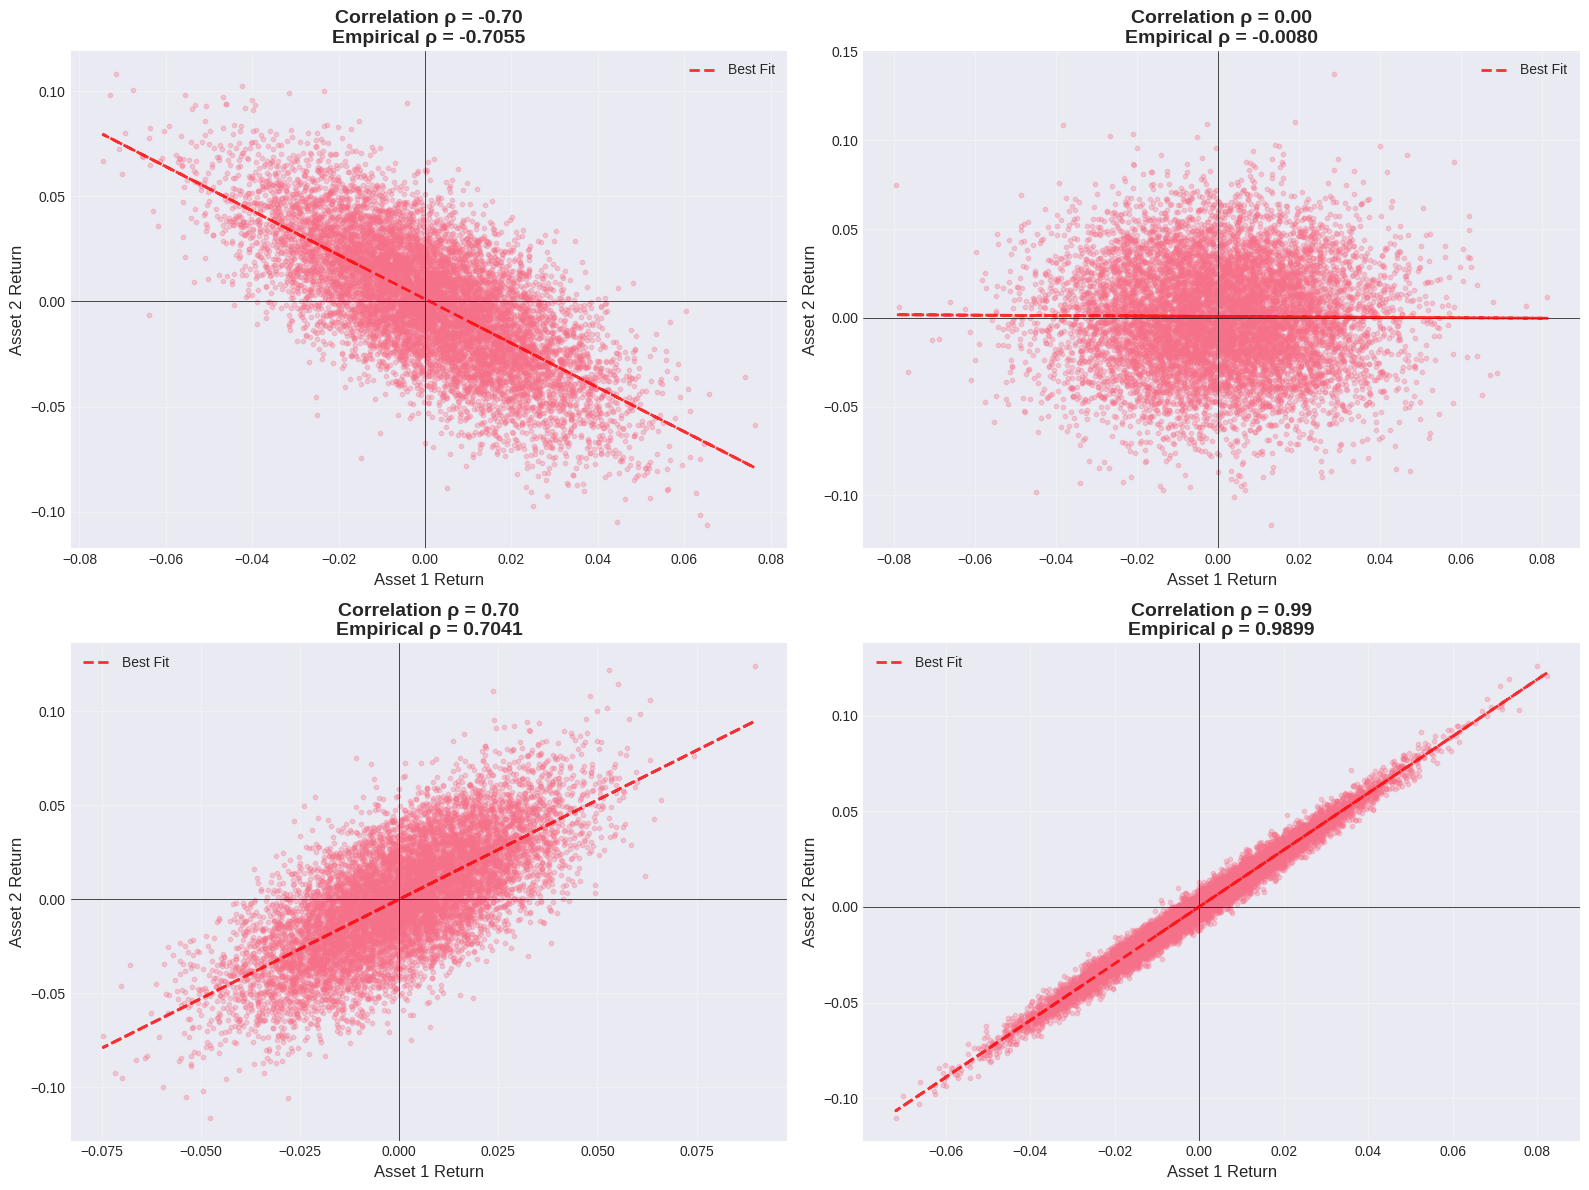

In [9]:
# ========================================
# Simulating Correlated Assets
# ========================================

def simulate_correlated_assets(
    rho: float,
    n: int = 10000,
    mu1: float = 0.0005,
    mu2: float = 0.0008,
    sigma1: float = 0.02,
    sigma2: float = 0.03
) -> Tuple[np.ndarray, np.ndarray]:
    """Simulate two correlated assets."""
    cov_matrix = np.array([
        [sigma1**2, rho * sigma1 * sigma2],
        [rho * sigma1 * sigma2, sigma2**2]
    ])
    
    mean_vector = np.array([mu1, mu2])
    data = np.random.multivariate_normal(mean_vector, cov_matrix, n)
    
    return data[:, 0], data[:, 1]

# Simulate different correlation scenarios
correlations = [-0.7, 0.0, 0.7, 0.99]
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for idx, rho in enumerate(correlations):
    asset1, asset2 = simulate_correlated_assets(rho, 10000)
    
    axes[idx].scatter(asset1, asset2, alpha=0.3, s=10)
    axes[idx].set_title(f'Correlation ρ = {rho:.2f}\nEmpirical ρ = {np.corrcoef(asset1, asset2)[0,1]:.4f}', 
                       fontweight='bold')
    axes[idx].set_xlabel('Asset 1 Return')
    axes[idx].set_ylabel('Asset 2 Return')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].axhline(0, color='black', linewidth=0.5)
    axes[idx].axvline(0, color='black', linewidth=0.5)
    
    # Add regression line
    z = np.polyfit(asset1, asset2, 1)
    p = np.poly1d(z)
    axes[idx].plot(asset1, p(asset1), "r--", alpha=0.8, linewidth=2, label='Best Fit')
    axes[idx].legend()

plt.tight_layout()
plt.show()

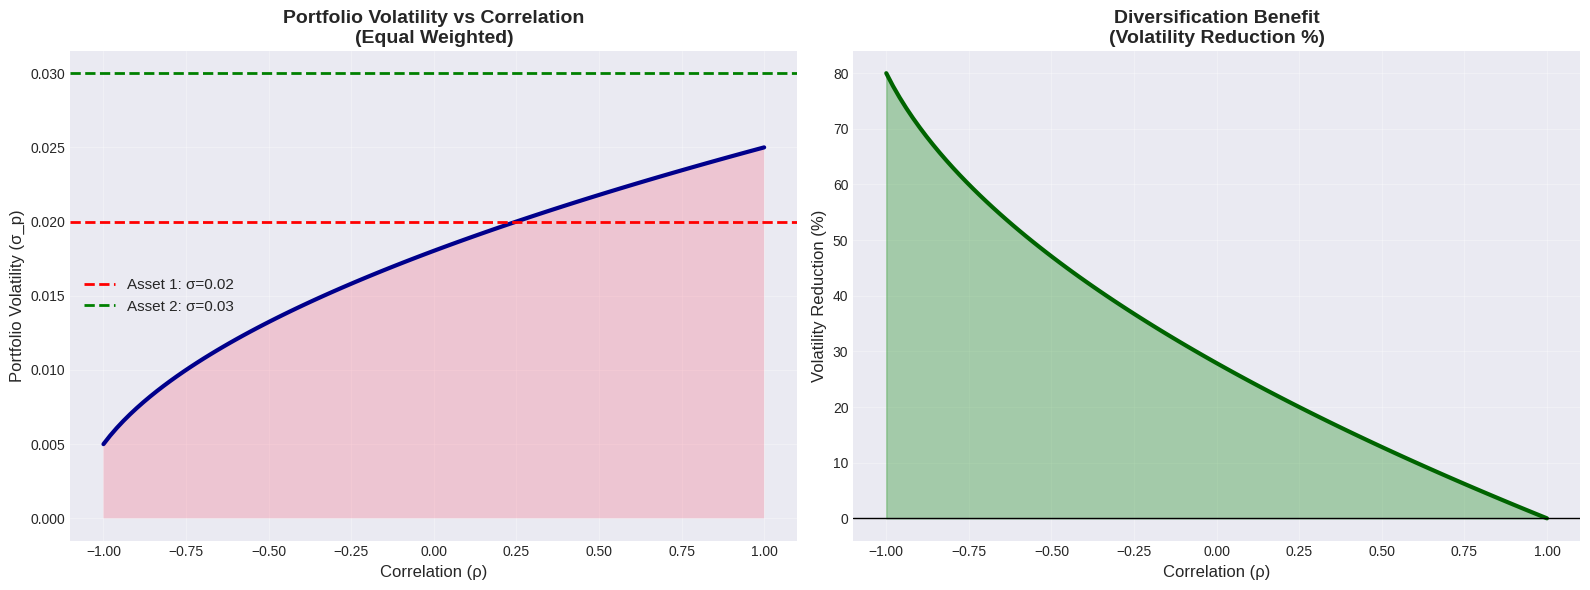


💡 Maximum diversification occurs at ρ = -1
💡 No diversification benefit when ρ = +1


In [10]:
# ========================================
# Portfolio Variance and Diversification
# ========================================

def portfolio_variance(w1, w2, sigma1, sigma2, rho):
    """Calculate two-asset portfolio variance."""
    return (w1**2 * sigma1**2 + 
            w2**2 * sigma2**2 + 
            2 * w1 * w2 * rho * sigma1 * sigma2)

sigma1, sigma2 = 0.02, 0.03
w1, w2 = 0.5, 0.5

rho_range = np.linspace(-1, 1, 100)
port_variance = [portfolio_variance(w1, w2, sigma1, sigma2, rho) for rho in rho_range]
port_volatility = [np.sqrt(v) for v in port_variance]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Portfolio volatility vs correlation
ax1.plot(rho_range, port_volatility, linewidth=3, color='darkblue')
ax1.axhline(sigma1, color='red', linestyle='--', label=f'Asset 1: σ={sigma1}', linewidth=2)
ax1.axhline(sigma2, color='green', linestyle='--', label=f'Asset 2: σ={sigma2}', linewidth=2)
ax1.fill_between(rho_range, 0, port_volatility, alpha=0.3)
ax1.set_title('Portfolio Volatility vs Correlation\n(Equal Weighted)', fontweight='bold', fontsize=14)
ax1.set_xlabel('Correlation (ρ)', fontsize=12)
ax1.set_ylabel('Portfolio Volatility (σ_p)', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Diversification benefit
naive_volatility = w1 * sigma1 + w2 * sigma2
diversification_benefit = [(naive_volatility - pv) / naive_volatility * 100 for pv in port_volatility]

ax2.plot(rho_range, diversification_benefit, linewidth=3, color='darkgreen')
ax2.fill_between(rho_range, 0, diversification_benefit, alpha=0.3, color='green')
ax2.axhline(0, color='black', linewidth=1)
ax2.set_title('Diversification Benefit\n(Volatility Reduction %)', fontweight='bold', fontsize=14)
ax2.set_xlabel('Correlation (ρ)', fontsize=12)
ax2.set_ylabel('Volatility Reduction (%)', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 Maximum diversification occurs at ρ = -1")
print("💡 No diversification benefit when ρ = +1")

---

## 4. Law of Large Numbers and Central Limit Theorem

### 4.1 Law of Large Numbers (LLN)

**Statement**: As sample size increases, sample mean converges to population mean.

$$\bar{X}_n = \frac{1}{n}\sum_{i=1}^n X_i \xrightarrow{P} \mu \quad \text{as } n \to \infty$$

**Trading Implication**: Your edge only appears with sufficient repetitions. This theorem is psychologically important. Your edge only appears with enough repetitions. Short-term performance is noise. Without sufficient trades, you cannot distinguish skill from variance. The LLN teaches patience. 

### 4.2 Central Limit Theorem (CLT)

**Statement**: Distribution of sample means approaches normal distribution.

$$\sqrt{n}\left(\bar{X}_n - \mu\right) \xrightarrow{d} \mathcal{N}(0, \sigma^2) \quad \text{as } n \to \infty$$

**Standard error**:
$$\text{SE}(\bar{X}) = \frac{\sigma}{\sqrt{n}}$$

To halve the standard error, you need **4× the sample size**.

Regardless of underlying distribution (under mild conditions), the distribution of sample means tend toward normality. This result enables:
- Confidence intervals
- Hypothesis testing
- Sharpe ratio approximations

The CLT is why statistical inference is possible in finance. But it also reminds us:
> Inference is approximate, not absolute.

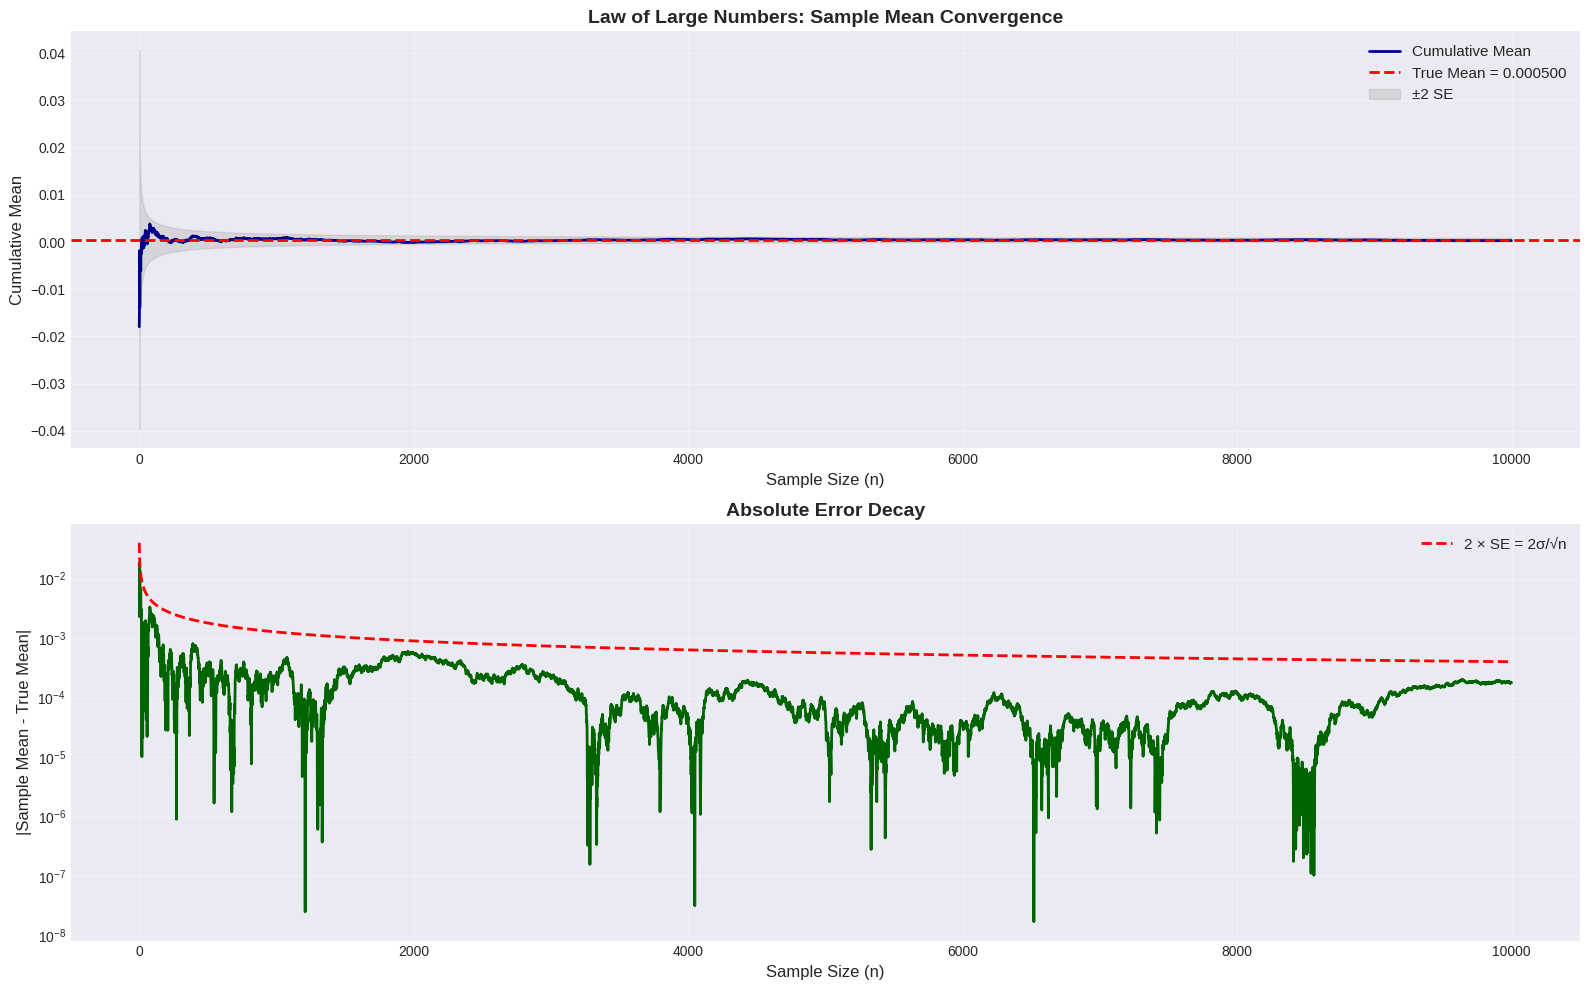


💡 Notice how variance of estimate decreases as O(1/√n)
💡 To halve the error, you need 4× the sample size!


In [11]:
# ========================================
# Law of Large Numbers Visualization
# ========================================

def demonstrate_lln(returns, true_mean):
    """Visualize LLN convergence."""
    n = len(returns)
    cumulative_means = np.cumsum(returns) / np.arange(1, n + 1)
    
    std = returns.std()
    sample_sizes = np.arange(1, n + 1)
    standard_errors = std / np.sqrt(sample_sizes)
    upper_band = true_mean + 2 * standard_errors
    lower_band = true_mean - 2 * standard_errors
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))
    
    # Cumulative mean convergence
    ax1.plot(cumulative_means, linewidth=2, label='Cumulative Mean', color='darkblue')
    ax1.axhline(true_mean, color='red', linestyle='--', linewidth=2, label=f'True Mean = {true_mean:.6f}')
    ax1.fill_between(range(n), lower_band, upper_band, alpha=0.2, color='gray', label='±2 SE')
    ax1.set_title('Law of Large Numbers: Sample Mean Convergence', fontweight='bold', fontsize=14)
    ax1.set_xlabel('Sample Size (n)')
    ax1.set_ylabel('Cumulative Mean')
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)
    
    # Convergence rate
    abs_error = np.abs(cumulative_means - true_mean)
    ax2.plot(abs_error, linewidth=2, color='darkgreen')
    ax2.plot(2 * standard_errors, linewidth=2, linestyle='--', color='red', label='2 × SE = 2σ/√n')
    ax2.set_title('Absolute Error Decay', fontweight='bold', fontsize=14)
    ax2.set_xlabel('Sample Size (n)')
    ax2.set_ylabel('|Sample Mean - True Mean|')
    ax2.set_yscale('log')
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

demonstrate_lln(returns_normal, mu_daily)

print("\n💡 Notice how variance of estimate decreases as O(1/√n)")
print("💡 To halve the error, you need 4× the sample size!")

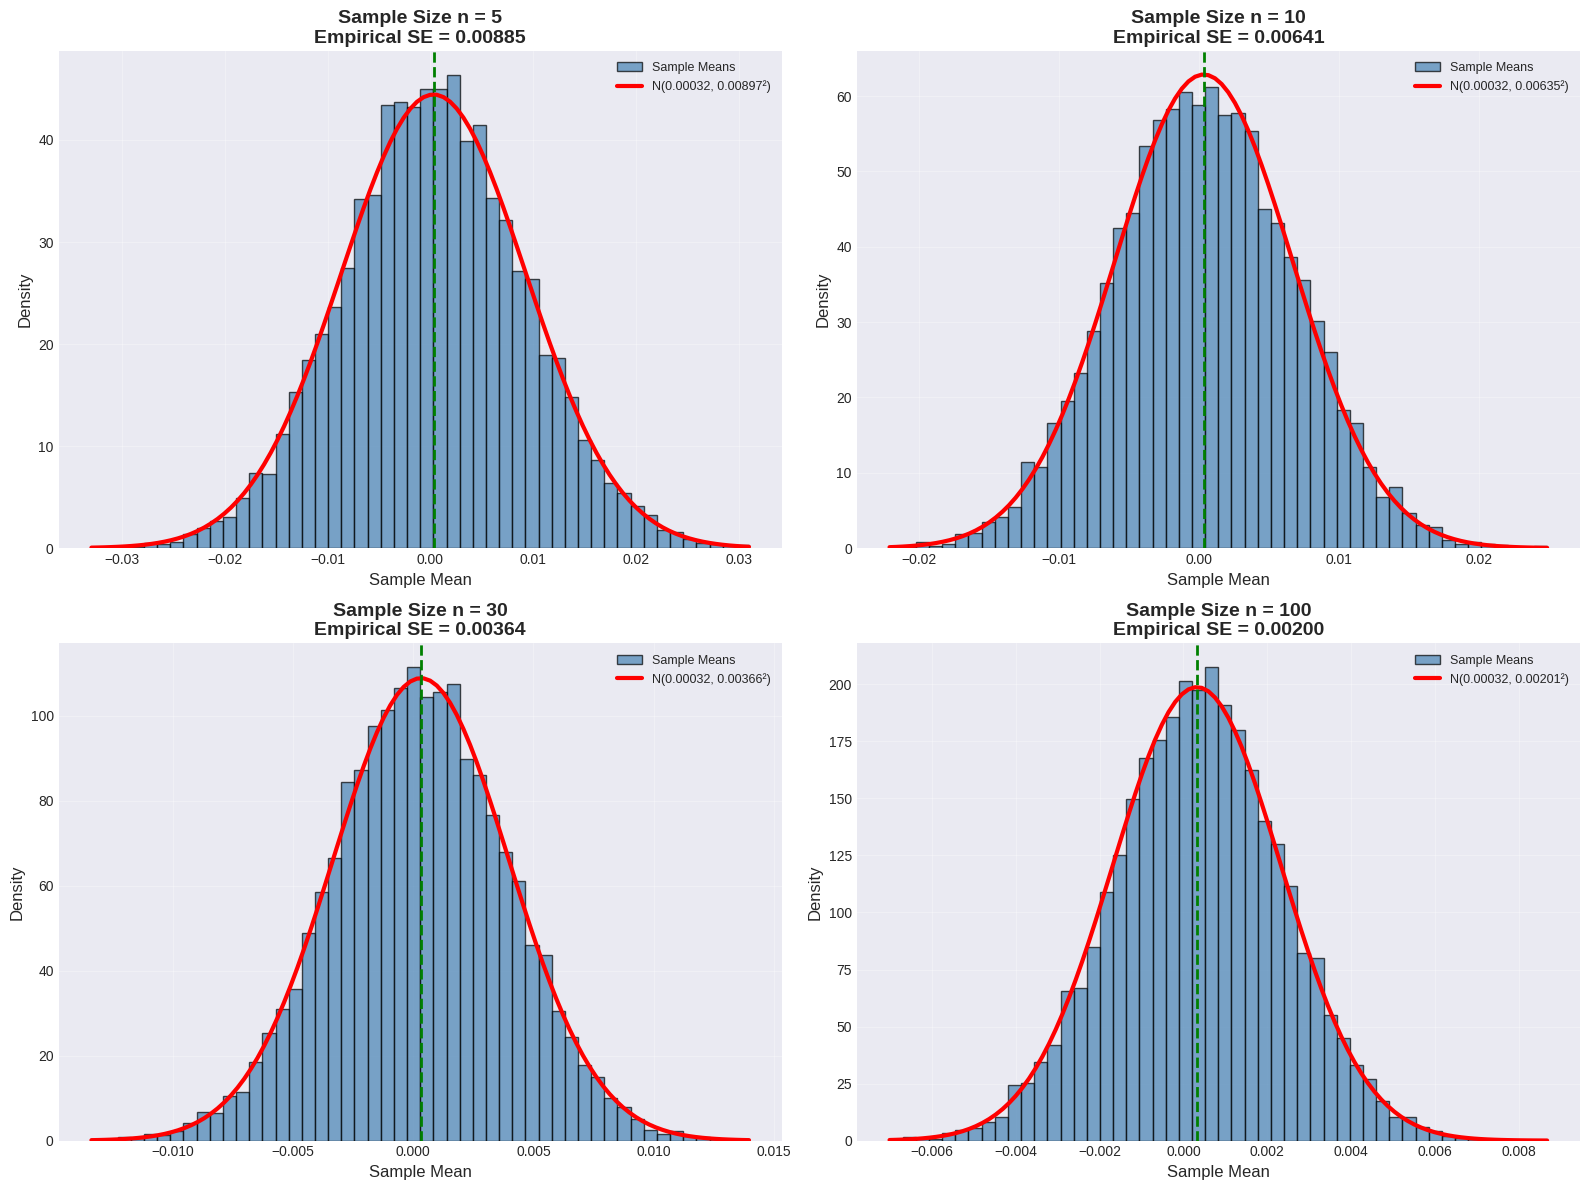


💡 Sampling distribution becomes more normal as n increases
💡 This is why we can use normal-based inference!


In [12]:
# ========================================
# Central Limit Theorem Demonstration
# ========================================

def demonstrate_clt(returns, sample_sizes=[5, 10, 30, 100], n_simulations=10000):
    """Demonstrate CLT with different sample sizes."""
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.ravel()
    
    true_mean = returns.mean()
    true_std = returns.std()
    
    for idx, n in enumerate(sample_sizes):
        sample_means = []
        for _ in range(n_simulations):
            sample = np.random.choice(returns, size=n, replace=True)
            sample_means.append(np.mean(sample))
        
        sample_means = np.array(sample_means)
        theoretical_se = true_std / np.sqrt(n)
        
        axes[idx].hist(sample_means, bins=50, density=True, alpha=0.7, 
                      color='steelblue', edgecolor='black', label='Sample Means')
        
        x = np.linspace(sample_means.min(), sample_means.max(), 100)
        theoretical_pdf = stats.norm.pdf(x, true_mean, theoretical_se)
        axes[idx].plot(x, theoretical_pdf, 'r-', linewidth=3, 
                      label=f'N({true_mean:.5f}, {theoretical_se:.5f}²)')
        
        axes[idx].axvline(true_mean, color='green', linestyle='--', linewidth=2)
        axes[idx].set_title(f'Sample Size n = {n}\nEmpirical SE = {sample_means.std():.5f}', 
                           fontweight='bold')
        axes[idx].set_xlabel('Sample Mean')
        axes[idx].set_ylabel('Density')
        axes[idx].legend(fontsize=9)
        axes[idx].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

demonstrate_clt(returns_normal)

print("\n💡 Sampling distribution becomes more normal as n increases")
print("💡 This is why we can use normal-based inference!")

---

## 5. Hypothesis Testing in Trading

### 5.1 The Fundamental Question
In trading, we constantly ask:

> *"Is this strategy truly profitable, or just random luck?"*

### 5.2 Classical Hypothesis Testing

**Hypotheses**:
$$H_0: \mu = 0 \quad \text{(no edge)}$$
$$H_1: \mu \neq 0 \quad \text{(has edge)}$$

**Test statistic**:
We compute a test statistic:

$$t = \frac{\bar{X} - \mu_0}{s / \sqrt{n}}$$

Then compute a p-value.

**p-value**:
$$p = \mathbb{P}(|T| \geq |t| \mid H_0 \text{ is true})$$

### 5.3 Type I and Type II Errors

| Decision | $H_0$ True | $H_0$ False |
|----------|-----------|-------------|
| **Reject $H_0$** | Type I (α) | Correct (Power) |
| **Fail to Reject** | Correct | Type II (β) |

### 5.4 Critical Warnings

1. **Data Snooping**: Testing 20 strategies at α=0.05 gives ~64% chance of false positive
2. **Overfitting**: Backtesting on development data creates inflated statistics
3. **Statistical ≠ Economic Significance**: p<0.05 doesn't mean profitable after costs

### 5.5 Philosophical Warning
If the p-value is small, we reject the null hypothesis.

However:

- Markets adapt.
- Data-snooping inflates significance.
- Overfitting produces false edges.

Statistical significance does not equal economic significance.

Professional quants understand that hypothesis testing is a filter — not a guarantee.
Small p-values do not guarantee profitability.

In [13]:
# ========================================
# Hypothesis Testing: t-test
# ========================================

def perform_t_test(returns, mu_null=0.0, alpha=0.05):
    """Perform one-sample t-test."""
    n = len(returns)
    sample_mean = np.mean(returns)
    sample_std = np.std(returns, ddof=1)
    se = sample_std / np.sqrt(n)
    
    t_stat = (sample_mean - mu_null) / se
    p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df=n-1))
    t_critical = stats.t.ppf(1 - alpha/2, df=n-1)
    
    ci_lower = sample_mean - t_critical * se
    ci_upper = sample_mean + t_critical * se
    
    reject_null = p_value < alpha
    
    return {
        'sample_mean': sample_mean,
        'sample_std': sample_std,
        'sample_size': n,
        't_statistic': t_stat,
        'p_value': p_value,
        't_critical': t_critical,
        'ci_95': (ci_lower, ci_upper),
        'reject_null': reject_null,
    }

results = perform_t_test(returns_normal)

print("\n" + "="*70)
print("ONE-SAMPLE T-TEST RESULTS")
print("="*70)
print(f"Sample Mean: {results['sample_mean']:.6f}")
print(f"t-statistic: {results['t_statistic']:.4f}")
print(f"p-value: {results['p_value']:.6f}")
print(f"95% CI: [{results['ci_95'][0]:.6f}, {results['ci_95'][1]:.6f}]")
print("\n" + "-"*70)
if results['reject_null']:
    print("✓ REJECT H₀: Evidence of edge")
else:
    print("✗ FAIL TO REJECT H₀: Insufficient evidence")
print("="*70)


ONE-SAMPLE T-TEST RESULTS
Sample Mean: 0.000321
t-statistic: 1.5985
p-value: 0.109957
95% CI: [-0.000073, 0.000714]

----------------------------------------------------------------------
✗ FAIL TO REJECT H₀: Insufficient evidence


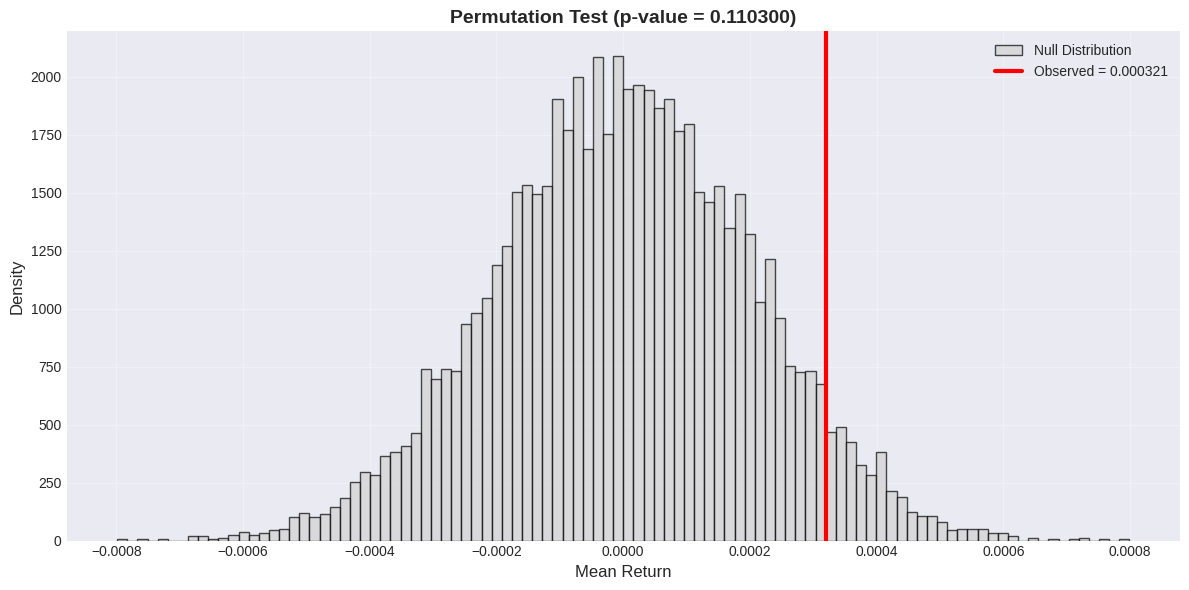


p-value: 0.110300
💡 Permutation tests are distribution-free!


In [15]:
# ========================================
# Monte Carlo Permutation Test
# ========================================

def monte_carlo_permutation_test(returns, n_permutations=10000):
    """Non-parametric permutation test."""
    observed_mean = np.mean(returns)
    n = len(returns)
    
    null_means = []
    for _ in range(n_permutations):
        signs = np.random.choice([-1, 1], size=n)
        permuted_returns = returns * signs
        null_means.append(np.mean(permuted_returns))
    
    null_means = np.array(null_means)
    p_value = np.mean(np.abs(null_means) >= np.abs(observed_mean))
    
    return {
        'observed_mean': observed_mean,
        'null_means': null_means,
        'p_value': p_value
    }

perm_results = monte_carlo_permutation_test(returns_normal)

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(perm_results['null_means'], bins=100, density=True, alpha=0.7, 
        color='lightgray', edgecolor='black', label='Null Distribution')
ax.axvline(perm_results['observed_mean'], color='red', linewidth=3, 
          label=f'Observed = {perm_results["observed_mean"]:.6f}')
ax.set_title(f'Permutation Test (p-value = {perm_results["p_value"]:.6f})', 
            fontweight='bold', fontsize=14)
ax.set_xlabel('Mean Return')
ax.set_ylabel('Density')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\np-value: {perm_results['p_value']:.6f}")
print("💡 Permutation tests are distribution-free!")

---

## Final Reflection: The Professional Mindset
Probability theory and statistics are not academic prerequisites. They are survival tools. 
Quant finance is not prediction. It is structured reasoning under uncertainty.

### Core Principles

**A professional quantitative trader**:

1. **Thinks in distributions, not outcomes**
2. **Understands dependence structures**
3. **Respects variance and tail risk**
4. **Uses LLN for patience**
5. **Applies hypothesis testing cautiously**

---

### Remember

Markets punish certainty. They reward disciplined probabilistic reasoning. Quantitative finance is not prediction.


> *"The market is not a deterministic machine. It is a probabilistic system, and you operate inside its distribution."*

Your job is not to predict the future.

Your job is to:
1. Model uncertainty honestly
2. Identify positive expected value
3. Size positions to survive variance
4. Compound edge over repetitions


It is the art of making decisions under uncertainty while minimizing self-deception.

Before you build strategies, optimize portfolios, or deploy models, you must internalize this:

> The market is not a deterministic machine.
>
> It is a probabilistic system and you operate inside its distribution.

In the next module, we move from probability to linear algebra — the geometry of risk — and see how covariance structures shape portfolio construction.

---

**End of Module 1.1**

*Next: Module 1.2 — Linear Algebra for Portfolio Theory*